# ReproPilot - Unsloth + TRL GRPO Against The Deployed HF Space API

Post-train an instruction model with GRPO where the main reward is fetched from the live ReproPilot OpenEnv Space.

- Live endpoint: `https://riwaj43adz-repro.hf.space`
- Default base model: `unsloth/Qwen2.5-3B-Instruct`
- Algorithm: TRL `GRPOTrainer` through the normal Hugging Face `generate()` path
- Rewards: independent functions for live environment reward, JSON format, action semantics, and anti-idle behavior
- Output: local LoRA adapter, optionally pushed to a Hugging Face model repo

This notebook is designed to be uploaded as a single file to Google Colab. It does not clone or import the ReproPilot repo.


## Phase 1 - Pick The Task

Single-action audit policy learning. The model receives the `/reset` briefing from the deployed ReproPilot Space and must emit exactly one JSON action matching the ReproPilot `AgentAction` schema. The deployed Space scores that action through `/step`; that score is the GRPO learning signal.

This mirrors the previous notebook structure: train from the live API, then inspect generated actions against the same live API.


## Phase 2 - Build The Runtime

Run this cell first in Colab. It uses `!pip install` only and does not upgrade pip.


In [ ]:
%%capture
!pip install -q requests pydantic pandas matplotlib tqdm datasets huggingface_hub
!pip install -q unsloth trl accelerate bitsandbytes


In [ ]:
import os, sys, json, time, random, re, math, pathlib
from typing import Any, Literal

REPROPILOT_ENV_URL = os.environ.get('REPROPILOT_ENV_URL', 'https://riwaj43adz-repro.hf.space').rstrip('/')
MODEL_ID = os.environ.get('REPROPILOT_MODEL_ID', 'unsloth/Qwen2.5-3B-Instruct')
RUN_NAME = os.environ.get('RUN_NAME', 'repropilot-unsloth-grpo-live-api')
HUB_REPO_ID = os.environ.get('HF_MODEL_REPO_ID', 'riwaj43adz/repropilot-qwen2-5-3b-grpo')
PUSH_TO_HUB = os.environ.get('PUSH_TO_HUB', '0') == '1'
SEED = int(os.environ.get('REPROPILOT_SEED', '7'))

OUT = pathlib.Path('/content/repropilot_out') if pathlib.Path('/content').exists() else pathlib.Path('./repropilot_out')
OUT.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
os.environ.setdefault('WANDB_DISABLED', 'true')
os.environ.setdefault('HF_HUB_DISABLE_TELEMETRY', '1')
os.environ.setdefault('TRL_EXPERIMENTAL_SILENCE', '1')

print('Endpoint :', REPROPILOT_ENV_URL)
print('Model    :', MODEL_ID)
print('Run name :', RUN_NAME)
print('Output   :', OUT)
print('Hub repo :', HUB_REPO_ID if PUSH_TO_HUB else '(push disabled)')
print('HF token :', 'set' if os.environ.get('HF_TOKEN') else 'missing unless notebook_login is used')


Endpoint : https://riwaj43adz-repro.hf.space
Model    : unsloth/Qwen2.5-3B-Instruct
Run name : repropilot-unsloth-grpo-live-api
Output   : /content/repropilot_out
Hub repo : (push disabled)
HF token : missing unless notebook_login is used


### 2.1 HTTP Client To The Deployed Space

Every environment reward in this notebook comes from this client. `/step` uses OpenEnv's wrapped payload shape: `{"action": {...}}`.


In [ ]:
import requests

class ReproPilotSpace:
    def __init__(self, url: str, timeout: float = 60.0, max_retries: int = 4):
        self.url = url.rstrip('/')
        self.timeout = timeout
        self.max_retries = max_retries
        self.latency_ms: list[float] = []
        self.failures: list[str] = []

    def _post(self, path: str, payload: dict[str, Any]) -> dict[str, Any]:
        last_error: Exception | None = None
        for attempt in range(self.max_retries):
            t0 = time.perf_counter()
            try:
                response = requests.post(f'{self.url}{path}', json=payload, timeout=self.timeout)
                self.latency_ms.append((time.perf_counter() - t0) * 1000)
                if response.status_code >= 400:
                    raise RuntimeError(f'{response.status_code} {response.url}: {response.text[:1200]}')
                return response.json()
            except Exception as exc:
                last_error = exc
                self.failures.append(str(exc))
                time.sleep(min(2.0 * (attempt + 1), 8.0))
        raise RuntimeError(f'Space request failed after retries: {last_error}')

    def reset(self) -> dict[str, Any]:
        return self._post('/reset', {})

    def step(self, action: dict[str, Any]) -> dict[str, Any]:
        return self._post('/step', {'action': action})


env = ReproPilotSpace(REPROPILOT_ENV_URL)
reset_payload = env.reset()
print('reset keys:', sorted(reset_payload.keys()))
print(json.dumps(reset_payload, indent=2)[:1200])


reset keys: ['done', 'observation', 'reward']
{
  "observation": {
    "echoed_message": "REPROPILOT RESEARCH AUDIT BRIEFING\n\nScenario: split_mismatch_test_vs_val_001\nSteps remaining: 10\nClaim risk: 55/100\nEvidence confidence: 0/100\n\nTARGET CLAIM\n- ID: claim_001\n- Text: Our method achieves 91.2% test accuracy on Dataset X using Entropy-Gated Routing.\n- Type: metric_result\n- Claimed metric: accuracy = 0.912\n- Claimed dataset: Dataset X\n- Claimed split: test\n- Claimed method: Entropy-Gated Routing\n- Novelty level: 4/5\n\nPAPER SECTIONS\n- sec_abs: Abstract [abstract] inspected=False :: We study Dataset X and report Our method achieves 91.2% test accuracy on Dataset X using Entropy-Gated Routing..\n- sec_method: Method [method] inspected=False :: The method uses Entropy-Gated Routing with calibrated scoring.\n- sec_exp: Experiments [experiments] inspected=False :: Experiments compare the full method against baselines.\n\nREPOSITORY / ARTIFACTS\n- file_eval: repo/evaluate.py

In [ ]:
def unwrap_observation(payload: dict[str, Any]) -> dict[str, Any]:
    inner = payload.get('observation') if isinstance(payload, dict) else None
    if isinstance(inner, dict):
        return inner
    return payload


def briefing_from_reset(payload: dict[str, Any]) -> str:
    obs = unwrap_observation(payload)
    text = obs.get('echoed_message') or obs.get('message') or obs.get('text')
    if not isinstance(text, str) or not text.strip():
        raise RuntimeError(f'Space returned no briefing. keys={list(obs.keys())}')
    return text

briefing = briefing_from_reset(reset_payload)
print(briefing[:2000])


REPROPILOT RESEARCH AUDIT BRIEFING

Scenario: split_mismatch_test_vs_val_001
Steps remaining: 10
Claim risk: 55/100
Evidence confidence: 0/100

TARGET CLAIM
- ID: claim_001
- Text: Our method achieves 91.2% test accuracy on Dataset X using Entropy-Gated Routing.
- Type: metric_result
- Claimed metric: accuracy = 0.912
- Claimed dataset: Dataset X
- Claimed split: test
- Claimed method: Entropy-Gated Routing
- Novelty level: 4/5

PAPER SECTIONS
- sec_abs: Abstract [abstract] inspected=False :: We study Dataset X and report Our method achieves 91.2% test accuracy on Dataset X using Entropy-Gated Routing..
- sec_method: Method [method] inspected=False :: The method uses Entropy-Gated Routing with calibrated scoring.
- sec_exp: Experiments [experiments] inspected=False :: Experiments compare the full method against baselines.

REPOSITORY / ARTIFACTS
- file_eval: repo/evaluate.py [code_file] inspected=False :: dataset = load_dataset(split="validation") accuracy = accuracy_score(y_true, y_pr

### 2.2 Verifier Sanity Check

Fire representative legal actions once. If all rewards are identical or every step fails, GRPO cannot learn from the verifier.


In [ ]:
LEGAL_ACTION_TYPES = [
    'read_claim',
    'inspect_paper_section',
    'inspect_code_file',
    'inspect_config',
    'inspect_logs',
    'inspect_result_table',
    'inspect_dataset_card',
    'inspect_checkpoint',
    'search_artifacts',
    'compare_claim_to_artifacts',
    'audit_experiment_design',
    'rank_evidence',
    'plan_next_check',
    'run_metric_check',
    'run_split_check',
    'run_leakage_check',
    'run_seed_check',
    'run_ablation_check',
    'run_paper_code_consistency_check',
    'run_reproduction_check',
    'run_dataset_provenance_check',
    'run_hyperparameter_search_check',
    'run_baseline_fairness_check',
    'run_statistical_significance_check',
    'run_implementation_completeness_check',
    'synthesize_findings',
    'mark_inconclusive',
    'submit_verdict',
    'do_nothing',
]
VERDICTS = [
    'SUPPORTED_RESULT_AND_METHOD',
    'PLAUSIBLY_VALIDATED_NOVEL_METHOD',
    'NOT_SUPPORTED_RESULT_MISMATCH',
    'NOT_SUPPORTED_METHOD_INVALID',
    'INCONCLUSIVE_MISSING_ARTIFACTS',
    'INCONCLUSIVE_NEEDS_DOMAIN_REVIEW',
    'NOT_ENOUGH_EVIDENCE',
]
FAILURE_TYPES = [
    'none',
    'metric_mismatch',
    'split_mismatch',
    'data_leakage',
    'cherry_picked_seed',
    'paper_code_mismatch',
    'invalid_ablation',
    'result_mismatch',
    'missing_artifact',
    'ambiguous_method',
    'unsupported_claim',
    'unknown',
]

SMOKE_ACTIONS = [
    {'action_type': 'read_claim', 'explanation': 'Read the target research claim.'},
    {'action_type': 'search_artifacts', 'target_id': 'split', 'explanation': 'Search for split-related artifacts.'},
    {'action_type': 'run_split_check', 'target_id': 'claim_001', 'explanation': 'Verify whether claimed and implemented splits match.'},
    {'action_type': 'run_metric_check', 'target_id': 'claim_001', 'explanation': 'Verify whether claimed and logged metrics match.'},
    {'action_type': 'do_nothing', 'explanation': 'No audit action.'},
]

smoke_rows = []
for action in SMOKE_ACTIONS:
    payload = env.step(action)
    obs = unwrap_observation(payload)
    smoke_rows.append({
        'action_type': action['action_type'],
        'reward': payload.get('reward', obs.get('reward')),
        'done': payload.get('done', obs.get('done')),
        'result': (obs.get('metadata') or {}).get('last_action_result'),
    })

for row in smoke_rows:
    print(row)

rewards = [r['reward'] for r in smoke_rows if isinstance(r.get('reward'), (int, float))]
if len(set(rewards)) <= 1:
    raise RuntimeError(f'Degenerate verifier rewards: {rewards}')


{'action_type': 'read_claim', 'reward': 0.02, 'done': False, 'result': None}
{'action_type': 'search_artifacts', 'reward': 0.18, 'done': False, 'result': None}
{'action_type': 'run_split_check', 'reward': 0.45, 'done': False, 'result': None}
{'action_type': 'run_metric_check', 'reward': 0.18, 'done': False, 'result': None}
{'action_type': 'do_nothing', 'reward': -0.25, 'done': False, 'result': None}


## Phase 3 - Build Rewards

The live environment reward is the main signal. The other rewards are independent guardrails so the trainer can learn the output contract before environment rewards become consistently useful.


In [ ]:
from pydantic import BaseModel, Field

class ReproPilotAction(BaseModel):
    action_type: Literal[
        'read_claim',
        'inspect_paper_section',
        'inspect_code_file',
        'inspect_config',
        'inspect_logs',
        'inspect_result_table',
        'inspect_dataset_card',
        'inspect_checkpoint',
        'search_artifacts',
        'compare_claim_to_artifacts',
        'run_metric_check',
        'run_split_check',
        'run_leakage_check',
        'run_seed_check',
        'run_ablation_check',
        'run_paper_code_consistency_check',
        'run_reproduction_check',
        'synthesize_findings',
        'mark_inconclusive',
        'submit_verdict',
        'do_nothing',
    ] = 'do_nothing'
    target_id: str | None = None
    secondary_id: str | None = None
    verdict: str | None = None
    failure_type: str | None = None
    evidence_ids: list[str] = Field(default_factory=list)
    explanation: str | None = None
    generated_code: str | None = None

_JSON_RE = re.compile(r'\{[^{}]*(?:\{[^{}]*\}[^{}]*)*\}', re.DOTALL)

def completion_text(c: Any) -> str:
    if isinstance(c, list) and c and isinstance(c[0], dict):
        return str(c[0].get('content', ''))
    return c if isinstance(c, str) else str(c)


def parse_action(text: str) -> tuple[dict[str, Any] | None, str | None]:
    cleaned = re.sub(r'<think>.*?</think>', '', text, flags=re.DOTALL).strip()
    matches = list(_JSON_RE.finditer(cleaned))
    if not matches:
        return None, 'no_json'
    try:
        obj = json.loads(matches[-1].group(0))
    except json.JSONDecodeError as exc:
        return None, f'bad_json:{exc.msg}'
    try:
        action = ReproPilotAction(**obj).model_dump(exclude_none=True)
    except Exception as exc:
        return None, f'bad_schema:{type(exc).__name__}'
    return action, None


def as_reward(payload: dict[str, Any]) -> float:
    obs = unwrap_observation(payload)
    val = payload.get('reward', obs.get('reward'))
    return float(val or 0.0)


In [ ]:
def format_reward(completions: list[Any], **_: Any) -> list[float]:
    scores = []
    for completion in completions:
        text = completion_text(completion).strip()
        action, error = parse_action(text)
        if error is None and action is not None and text.startswith('{') and text.endswith('}'):
            scores.append(0.25)
        elif error is None:
            scores.append(0.10)
        else:
            scores.append(-0.35)
    return scores


def action_matches_objective(action: dict[str, Any], objective: str | None) -> bool:
    at = action.get('action_type')
    target = (action.get('target_id') or action.get('explanation') or '').lower()
    if objective == 'inspect_code': return at == 'inspect_code_file'
    if objective == 'inspect_config': return at == 'inspect_config'
    if objective == 'inspect_logs': return at == 'inspect_logs'
    if objective == 'search_metric': return at == 'search_artifacts' and any(k in target for k in ['metric', 'accuracy', 'result'])
    if objective == 'run_split': return at == 'run_split_check'
    if objective == 'run_metric': return at == 'run_metric_check'
    if objective == 'experiment_design': return at == 'audit_experiment_design'
    if objective == 'compare': return at == 'compare_claim_to_artifacts'
    if objective == 'plan': return at == 'plan_next_check'
    if objective == 'synthesize': return at == 'synthesize_findings'
    return False


def objective_reward(prompts: list[str], completions: list[Any], **_: Any) -> list[float]:
    scores = []
    for prompt, completion in zip(prompts, completions):
        action, error = parse_action(completion_text(completion))
        objective = OBJECTIVE_BY_PROMPT.get(prompt)
        if action is None or error is not None:
            scores.append(-0.50)
        elif action_matches_objective(action, objective):
            scores.append(0.90)
        else:
            scores.append(-0.20)
    return scores


def audit_policy_reward(completions: list[Any], **_: Any) -> list[float]:
    scores = []
    for completion in completions:
        action, error = parse_action(completion_text(completion))
        if action is None or error is not None:
            scores.append(-0.60)
            continue
        at = action.get('action_type')
        score = 0.0
        if at == 'do_nothing': score -= 0.35
        elif at == 'read_claim': score -= 0.10
        elif at in {'inspect_paper_section', 'inspect_code_file', 'inspect_config', 'inspect_logs', 'inspect_result_table', 'inspect_dataset_card', 'inspect_checkpoint'}:
            score += 0.30 if action.get('target_id') else 0.05
        elif at == 'compare_claim_to_artifacts': score += 0.75
        elif at == 'audit_experiment_design': score += 0.80
        elif at == 'rank_evidence': score += 0.35
        elif at == 'plan_next_check': score += 0.30
        elif at == 'search_artifacts':
            query = (action.get('target_id') or action.get('explanation') or '').lower()
            score += 0.25 if any(k in query for k in ['metric', 'split', 'seed', 'artifact', 'result', 'leakage']) else 0.05
        elif at in {'run_metric_check', 'run_split_check', 'run_leakage_check', 'run_seed_check', 'run_ablation_check', 'run_paper_code_consistency_check', 'run_reproduction_check', 'run_dataset_provenance_check', 'run_hyperparameter_search_check', 'run_baseline_fairness_check', 'run_statistical_significance_check', 'run_implementation_completeness_check'}:
            score += 0.55 if action.get('target_id') else 0.30
            if at in {'run_split_check', 'run_metric_check'}: score += 0.15
        elif at == 'synthesize_findings': score += 0.25
        elif at == 'mark_inconclusive': score += 0.05
        elif at == 'submit_verdict':
            has_verdict = action.get('verdict') in VERDICTS
            has_failure = action.get('failure_type') in FAILURE_TYPES
            score += 0.20 if has_verdict and has_failure else -0.10
        if action.get('explanation'): score += 0.05
        scores.append(score)
    return scores


def anti_idle_reward(completions: list[Any], **_: Any) -> list[float]:
    scores = []
    for completion in completions:
        action, error = parse_action(completion_text(completion))
        if action is None or error is not None: scores.append(-0.25)
        elif action.get('action_type') in {'do_nothing', 'read_claim'}: scores.append(-0.15)
        else: scores.append(0.10)
    return scores


def env_reward(completions: list[Any], **_: Any) -> list[float]:
    scores = []
    squash = os.environ.get('REPROPILOT_REWARD_SQUASH', '1') == '1'
    scale = float(os.environ.get('REPROPILOT_REWARD_SQUASH_SCALE', '2.5'))
    for completion in completions:
        action, error = parse_action(completion_text(completion))
        if action is None or error is not None:
            scores.append(-1.0)
            continue
        try:
            payload = env.step(action)
            reward = as_reward(payload)
            scores.append(math.tanh(reward / scale) if squash else reward)
        except Exception as exc:
            env.failures.append(str(exc))
            scores.append(-1.0)
    return scores

reward_funcs = [objective_reward, env_reward, format_reward, audit_policy_reward, anti_idle_reward]

probe_actions = [
    '{"action_type":"inspect_code_file","target_id":"file_eval","explanation":"Inspect evaluation code."}',
    '{"action_type":"run_split_check","target_id":"claim_001","explanation":"Verify split consistency."}',
    '{"action_type":"audit_experiment_design","target_id":"claim_001","explanation":"Audit experiment design."}',
]
print('env', env_reward(probe_actions))
print('format', format_reward(probe_actions))
print('audit_policy', audit_policy_reward(probe_actions))
print('anti_idle', anti_idle_reward(probe_actions))


env [0.07187584144881773, 0.17808086811733018, -1.0]
format [0.25, 0.25, -0.35]
audit_policy [0.35, 0.7500000000000001, -0.6]
anti_idle [0.1, 0.1, -0.25]


### 3.1 Tripwire Callback

Stop early if the trainer collapses to invalid JSON or `do_nothing`.


In [ ]:
from transformers import TrainerCallback

class ReproPilotTripwire(TrainerCallback):
    def __init__(self, *, window: int = 24, max_invalid_rate: float = 0.85, max_idle_rate: float = 0.75):
        self.window = window
        self.max_invalid_rate = max_invalid_rate
        self.max_idle_rate = max_idle_rate
        self.outputs: list[str] = []

    def remember(self, text: str) -> None:
        self.outputs.append(text)
        self.outputs = self.outputs[-self.window:]

    def on_step_end(self, args, state, control, **kwargs):
        if len(self.outputs) < self.window:
            return control
        parsed = [parse_action(x)[0] for x in self.outputs]
        invalid = sum(x is None for x in parsed) / len(parsed)
        idle = sum((x or {}).get('action_type') == 'do_nothing' for x in parsed) / len(parsed)
        if invalid > self.max_invalid_rate or idle > self.max_idle_rate:
            control.should_training_stop = True
            print(f'Tripwire stop: invalid={invalid:.2f} idle={idle:.2f}')
        return control


## Phase 4 - Deploy

Already deployed. Live Space: [`riwaj43adz/repro`](https://huggingface.co/spaces/riwaj43adz/repro). The smoke cells above confirm `/reset` and `/step` are reachable.


## Phase 5 - Train Small

Load the base model in 4-bit with Unsloth, attach LoRA, and run a short GRPO stage against the live Space API.


In [ ]:
from unsloth import FastLanguageModel
import torch

MAX_SEQ_LENGTH = int(os.environ.get('REPROPILOT_MAX_SEQ_LENGTH', '2048'))
policy, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_ID,
    max_seq_length=MAX_SEQ_LENGTH,
    load_in_4bit=True,
    fast_inference=False,
)
policy = FastLanguageModel.get_peft_model(
    policy,
    r=16,
    target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj'],
    lora_alpha=16,
    lora_dropout=0,
    bias='none',
    use_gradient_checkpointing='unsloth',
    random_state=SEED,
)
tokenizer.padding_side = 'left'
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
for cfg in [policy.config, policy.generation_config]:
    if hasattr(cfg, 'pad_token_id'):
        cfg.pad_token_id = tokenizer.pad_token_id
    if hasattr(cfg, 'eos_token_id'):
        cfg.eos_token_id = tokenizer.eos_token_id
    if hasattr(cfg, 'max_length'):
        cfg.max_length = None
print('loaded', MODEL_ID)


/tmp/ipykernel_1979/3590913327.py:1: UserWarning: WARNING: Unsloth should be imported before [transformers, peft] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth import FastLanguageModel


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA RTX PRO 6000 Blackwell Server Edition. Num GPUs = 1. Max memory: 94.971 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.36G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

...

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/qwen2.5-3b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.4.8 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


loaded unsloth/Qwen2.5-3B-Instruct


In [ ]:
SYSTEM_PROMPT = f'''
You are ReproPilot, a research-claim audit agent.
You receive a research audit briefing from an OpenEnv environment.
Return exactly one compact JSON object and no Markdown, no prose, no XML tags, no <think> block.

Allowed action_type values: {LEGAL_ACTION_TYPES}
Allowed verdict values: {VERDICTS}
Allowed failure_type values: {FAILURE_TYPES}

Good policy:
- Follow the AUDIT OBJECTIVE in the user message.
- The briefing already contains the claim; do not default to read_claim.
- Prefer inspection, search, plan_next_check, audit_experiment_design, compare_claim_to_artifacts, and deterministic check actions before submit_verdict.
- Use target_id claim_001 for claim-level checks when no better id is visible.
- Use explanations grounded in the briefing.
- Do not invent evidence_ids.
- Avoid do_nothing unless no useful action exists.

Valid examples:
{{"action_type":"run_split_check","target_id":"claim_001","explanation":"Verify whether the claimed test split matches the artifacts."}}
{{"action_type":"audit_experiment_design","target_id":"claim_001","explanation":"Audit split, leakage, hyperparameter search, baselines, and statistical evidence."}}
{{"action_type":"compare_claim_to_artifacts","target_id":"claim_001","explanation":"Compare the claim against available artifacts before choosing a verdict."}}
{{"action_type":"inspect_code_file","target_id":"file_eval","explanation":"Inspect evaluation code before judging the claim."}}
{{"action_type":"search_artifacts","target_id":"metric","explanation":"Search for metric evidence before judging support."}}
'''.strip()

AUDIT_OBJECTIVES = [
    ('inspect_code', 'Inspect the most relevant code artifact. Expected action family: inspect_code_file.'),
    ('inspect_config', 'Inspect the experiment configuration. Expected action family: inspect_config.'),
    ('inspect_logs', 'Inspect logs or result traces. Expected action family: inspect_logs.'),
    ('search_metric', 'Search artifacts for metric evidence. Expected action family: search_artifacts with a metric/result query.'),
    ('run_split', 'Run the split consistency check. Expected action family: run_split_check.'),
    ('run_metric', 'Run the metric consistency check. Expected action family: run_metric_check.'),
    ('experiment_design', 'Audit experiment design broadly. Expected action family: audit_experiment_design.'),
    ('compare', 'Compare the claim against available artifacts. Expected action family: compare_claim_to_artifacts.'),
    ('plan', 'Plan the next high-value check. Expected action family: plan_next_check.'),
    ('synthesize', 'Synthesize current findings. Expected action family: synthesize_findings.'),
]

OBJECTIVE_BY_PROMPT: dict[str, str] = {}

def build_prompt(brief: str, objective_key: str, objective_text: str) -> list[dict[str, str]]:
    user = brief + '\n\nAUDIT OBJECTIVE\n' + objective_text + '\n\nReturn one JSON action that satisfies the objective now.'
    return [{'role': 'system', 'content': SYSTEM_PROMPT}, {'role': 'user', 'content': user}]


def render_chat(messages: list[dict[str, str]]) -> str:
    if getattr(tokenizer, 'chat_template', None):
        try:
            return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True, enable_thinking=False)
        except TypeError:
            return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    return '\n'.join(f"{m['role'].upper()}: {m['content']}" for m in messages) + '\nASSISTANT:'


def fetch_briefing() -> str:
    return briefing_from_reset(env.reset())


In [ ]:
from datasets import Dataset
from tqdm.auto import tqdm

N_PROMPTS = int(os.environ.get('REPROPILOT_N_PROMPTS', '240'))
rows = []
briefings = []
for i in tqdm(range(N_PROMPTS), desc='fetch briefings'):
    brief = fetch_briefing()
    briefings.append(brief)
    objective_key, objective_text = AUDIT_OBJECTIVES[i % len(AUDIT_OBJECTIVES)]
    prompt = render_chat(build_prompt(brief, objective_key, objective_text))
    OBJECTIVE_BY_PROMPT[prompt] = objective_key
    rows.append({'prompt': prompt, 'objective': objective_key})

train_dataset = Dataset.from_list(rows)
print(train_dataset)
print(train_dataset[0]['objective'])
print(train_dataset[0]['prompt'][:1600])


fetch briefings:   0%|          | 0/240 [00:00<?, ?it/s]

Dataset({
    features: ['prompt', 'objective'],
    num_rows: 240
})
inspect_code
<|im_start|>system
You are ReproPilot, a research-claim audit agent.
You receive a research audit briefing from an OpenEnv environment.
Return exactly one compact JSON object and no Markdown, no prose, no XML tags, no <think> block.

Allowed action_type values: ['read_claim', 'inspect_paper_section', 'inspect_code_file', 'inspect_config', 'inspect_logs', 'inspect_result_table', 'inspect_dataset_card', 'inspect_checkpoint', 'search_artifacts', 'compare_claim_to_artifacts', 'audit_experiment_design', 'rank_evidence', 'plan_next_check', 'run_metric_check', 'run_split_check', 'run_leakage_check', 'run_seed_check', 'run_ablation_check', 'run_paper_code_consistency_check', 'run_reproduction_check', 'run_dataset_provenance_check', 'run_hyperparameter_search_check', 'run_baseline_fairness_check', 'run_statistical_significance_check', 'run_implementation_completeness_check', 'synthesize_findings', 'mark_inconclus

### 5.1 SFT Warm-Start For Action Routing

GRPO should not waste its first updates learning basic JSON routing. This small supervised stage teaches one correct action family per audit objective, then GRPO optimizes live rewards.


In [ ]:
SFT_EXAMPLES_PER_OBJECTIVE = int(os.environ.get('REPROPILOT_SFT_EXAMPLES_PER_OBJECTIVE', '18'))

def reference_action_for_objective(objective: str) -> dict[str, Any]:
    if objective == 'inspect_code':
        return {'action_type': 'inspect_code_file', 'target_id': 'file_eval', 'explanation': 'Inspect evaluation code for metric, split, and implementation details.'}
    if objective == 'inspect_config':
        return {'action_type': 'inspect_config', 'target_id': 'cfg_main', 'explanation': 'Inspect the main config for dataset, split, metric, seed, and hyperparameters.'}
    if objective == 'inspect_logs':
        return {'action_type': 'inspect_logs', 'target_id': 'log_val', 'explanation': 'Inspect logs for reported metric values, split, and seed behavior.'}
    if objective == 'search_metric':
        return {'action_type': 'search_artifacts', 'target_id': 'metric', 'explanation': 'Search artifacts for metric and result evidence.'}
    if objective == 'run_split':
        return {'action_type': 'run_split_check', 'target_id': 'claim_001', 'explanation': 'Check whether the claimed split matches artifact splits.'}
    if objective == 'run_metric':
        return {'action_type': 'run_metric_check', 'target_id': 'claim_001', 'explanation': 'Check whether the claimed metric matches artifact metrics.'}
    if objective == 'experiment_design':
        return {'action_type': 'audit_experiment_design', 'target_id': 'claim_001', 'explanation': 'Audit split, leakage, hyperparameter search, baselines, and statistical evidence.'}
    if objective == 'compare':
        return {'action_type': 'compare_claim_to_artifacts', 'target_id': 'claim_001', 'explanation': 'Compare the claim against visible paper, code, config, and log artifacts.'}
    if objective == 'plan':
        return {'action_type': 'plan_next_check', 'target_id': 'claim_001', 'explanation': 'Plan the next highest-value validation check.'}
    if objective == 'synthesize':
        return {'action_type': 'synthesize_findings', 'target_id': 'claim_001', 'explanation': 'Synthesize current checks and evidence into audit findings.'}
    return {'action_type': 'plan_next_check', 'target_id': 'claim_001', 'explanation': 'Plan the next audit step.'}

sft_rows = []
base_briefings = briefings if 'briefings' in globals() else [fetch_briefing() for _ in range(len(AUDIT_OBJECTIVES))]
for i in range(SFT_EXAMPLES_PER_OBJECTIVE * len(AUDIT_OBJECTIVES)):
    objective_key, objective_text = AUDIT_OBJECTIVES[i % len(AUDIT_OBJECTIVES)]
    brief = base_briefings[i % len(base_briefings)]
    prompt = render_chat(build_prompt(brief, objective_key, objective_text))
    answer = json.dumps(reference_action_for_objective(objective_key), separators=(',', ':'))
    sft_rows.append({'text': prompt + answer + (tokenizer.eos_token or '')})

sft_dataset = Dataset.from_list(sft_rows)
print(sft_dataset)
print(sft_dataset[0]['text'][-500:])


Dataset({
    features: ['text'],
    num_rows: 180
})
ing unfamiliar. If available checks pass but the method is novel, use PLAUSIBLY_VALIDATED_NOVEL_METHOD rather than claiming it is scientifically proven.

AUDIT OBJECTIVE
Inspect the most relevant code artifact. Expected action family: inspect_code_file.

Return one JSON action that satisfies the objective now.<|im_end|>
<|im_start|>assistant
{"action_type":"inspect_code_file","target_id":"file_eval","explanation":"Inspect evaluation code for metric, split, and implementation details."}<|im_end|>


In [ ]:
RUN_SFT = os.environ.get('RUN_SFT', '1') == '1'
if RUN_SFT:
    from transformers import TrainingArguments
    from trl import SFTTrainer
    import inspect

    sft_kwargs = {
        'output_dir': str(OUT / 'sft_warmstart'),
        'per_device_train_batch_size': int(os.environ.get('REPROPILOT_SFT_BATCH', '2')),
        'gradient_accumulation_steps': int(os.environ.get('REPROPILOT_SFT_ACCUM', '4')),
        'learning_rate': float(os.environ.get('REPROPILOT_SFT_LR', '8e-6')),
        'num_train_epochs': float(os.environ.get('REPROPILOT_SFT_EPOCHS', '2')),
        'logging_steps': 5,
        'save_strategy': 'no',
        'report_to': 'none',
        'fp16': not torch.cuda.is_bf16_supported(),
        'bf16': torch.cuda.is_bf16_supported(),
    }
    sft_args = TrainingArguments(**sft_kwargs)
    trainer_kwargs = {
        'model': policy,
        'tokenizer': tokenizer,
        'processing_class': tokenizer,
        'train_dataset': sft_dataset,
        'dataset_text_field': 'text',
        'max_seq_length': MAX_SEQ_LENGTH,
        'args': sft_args,
        'packing': False,
    }
    accepted = set(inspect.signature(SFTTrainer).parameters)
    sft_trainer = SFTTrainer(**{k: v for k, v in trainer_kwargs.items() if k in accepted})
    sft_trainer.train()
    print('SFT warm-start complete')
else:
    print('SFT skipped; set RUN_SFT=1 to enable')


Unsloth: Tokenizing ["text"] (num_proc=52):   0%|          | 0/180 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 180 | Num Epochs = 2 | Total steps = 46
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 29,933,568 of 3,115,872,256 (0.96% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss
5,2.776245
10,2.755871
15,2.727412
20,2.690894
25,2.657634
30,2.630435
35,2.604087
40,2.586887
45,2.578868


SFT warm-start complete


### 5.1 Baselines - Random Action And Frozen Model


In [ ]:
def random_action_json() -> str:
    at = random.choice(LEGAL_ACTION_TYPES)
    action = {'action_type': at, 'explanation': 'Random baseline action.'}
    if at.startswith('run_') or at in {'compare_claim_to_artifacts', 'audit_experiment_design'}:
        action['target_id'] = 'claim_001'
    if at == 'search_artifacts':
        action['target_id'] = random.choice(['metric', 'split', 'seed', 'artifact'])
    if at == 'submit_verdict':
        action.update({'verdict': random.choice(VERDICTS), 'failure_type': random.choice(FAILURE_TYPES), 'evidence_ids': []})
    return json.dumps(action, separators=(',', ':'))

N_EVAL = int(os.environ.get('REPROPILOT_N_EVAL', '8'))
random_rewards = env_reward([random_action_json() for _ in range(N_EVAL)])
print('random rewards:', random_rewards, 'mean=', sum(random_rewards) / len(random_rewards))


random rewards: [-1.0, -0.139092447878458, 0.007999829337702288, -1.0, 0.07187584144881773, -0.139092447878458, -0.139092447878458, -1.0] mean= -0.4171752091061067


### 5.2 Frozen Model JSON Preflight

Before GRPO, sample the base model. If it cannot produce valid JSON at least occasionally, RL will collapse to flat rewards.


In [ ]:
FastLanguageModel.for_inference(policy)

def sample_policy_json(prompt_text: str, *, temperature: float = 0.2) -> tuple[str, dict[str, Any] | None, str | None]:
    inputs = tokenizer(prompt_text, return_tensors='pt').to(policy.device)
    output = policy.generate(
        **inputs,
        max_new_tokens=96,
        do_sample=True,
        temperature=temperature,
        top_p=0.9,
        pad_token_id=tokenizer.eos_token_id,
    )
    text = tokenizer.decode(output[0][inputs['input_ids'].shape[-1]:], skip_special_tokens=True)
    action, error = parse_action(text)
    return text, action, error

preflight = []
for i in range(min(8, len(train_dataset))):
    text, action, error = sample_policy_json(train_dataset[i]['prompt'])
    preflight.append((text, action, error))

valid = sum(action is not None for _, action, _ in preflight)
print(f'valid_json={valid}/{len(preflight)}')
print('objectives:', [train_dataset[i]['objective'] for i in range(min(8, len(train_dataset)))])
for text, action, error in preflight[:3]:
    print('\n--- preflight ---')
    print(text[:700])
    print('parsed:', action, 'error:', error)

if valid == 0:
    raise RuntimeError('Base model produced 0 valid JSON actions. Switch MODEL_ID or fix prompt before GRPO.')


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API i

valid_json=7/8
objectives: ['inspect_code', 'inspect_config', 'inspect_logs', 'search_metric', 'run_split', 'run_metric', 'experiment_design', 'compare']

--- preflight ---
{"action_type":"inspect_code_file","target_id":"file_eval","explanation":"Inspect the evaluation code to verify the reported accuracy and ensure it aligns with the claimed method and dataset."}
parsed: {'action_type': 'inspect_code_file', 'target_id': 'file_eval', 'evidence_ids': [], 'explanation': 'Inspect the evaluation code to verify the reported accuracy and ensure it aligns with the claimed method and dataset.'} error: None

--- preflight ---
{"action_type":"inspect_config","target_id":"cfg_main","explanation":"Inspect the main configuration file to verify the claimed method and its parameters."}
parsed: {'action_type': 'inspect_config', 'target_id': 'cfg_main', 'evidence_ids': [], 'explanation': 'Inspect the main configuration file to verify the claimed method and its parameters.'} error: None

--- preflight -

### 5.2 Stage B - First GRPO Stage

Purpose: prove the training loop runs, the deployed Space is reachable during training, and rewards move.


In [ ]:
from trl import GRPOConfig, GRPOTrainer
import inspect

stage_logs: dict[str, list[dict[str, Any]]] = {}

def grpo_config(name: str, *, temperature: float, num_generations: int, max_steps: int, lr: float) -> GRPOConfig:
    max_steps = int(os.environ.get(f'REPROPILOT_{name}_STEPS', str(max_steps)))
    temperature = float(os.environ.get(f'REPROPILOT_{name}_TEMPERATURE', str(temperature)))
    lr = float(os.environ.get(f'REPROPILOT_{name}_LR', str(lr)))
    kwargs = {
        'output_dir': str(OUT / name),
        'run_name': f'{RUN_NAME}-{name}',
        'learning_rate': float(os.environ.get('REPROPILOT_GRPO_LR', str(lr))),
        'per_device_train_batch_size': 1,
        'gradient_accumulation_steps': int(os.environ.get('REPROPILOT_GRPO_ACCUM', '4')),
        'num_generations': int(os.environ.get('REPROPILOT_GENERATIONS', str(num_generations))),
        'max_prompt_length': int(os.environ.get('REPROPILOT_MAX_PROMPT_LENGTH', '1600')),
        'max_completion_length': int(os.environ.get('REPROPILOT_MAX_COMPLETION_LENGTH', '96')),
        'max_steps': max_steps,
        'temperature': temperature,
        'logging_steps': 1,
        'save_steps': max_steps,
        'report_to': 'none',
        'log_completions': False,
        'num_completions_to_print': 0,
    }
    accepted = set(inspect.signature(GRPOConfig).parameters)
    return GRPOConfig(**{k: v for k, v in kwargs.items() if k in accepted})


def run_stage(name: str, **kw: Any):
    cfg = grpo_config(name, **kw)
    trainer = GRPOTrainer(
        model=policy,
        processing_class=tokenizer,
        reward_funcs=reward_funcs,
        args=cfg,
        train_dataset=train_dataset,
    )
    result = trainer.train()
    stage_logs[name] = trainer.state.log_history
    print(name, result.metrics)
    return trainer

trainer_b = run_stage('B', temperature=0.60, num_generations=6, max_steps=160, lr=5e-6)


Unsloth: We now expect `per_device_train_batch_size` * `gradient_accumulation_steps` * `world_size` to be a multiple of `num_generations`.
We will change the batch size of 1 to the `num_generations` of 6


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 240 | Num Epochs = 3 | Total steps = 160
O^O/ \_/ \    Batch size per device = 6 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (6 x 4 x 1) = 24
 "-____-"     Trainable parameters = 29,933,568 of 3,115,872,256 (0.96% trained)
Passing `generation_config` together with generation-related arguments=({'cache_implementation', 'pad_token_id', 'disable_compile'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSA

Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / objective_reward / mean,rewards / objective_reward / std,rewards / env_reward / mean,rewards / env_reward / std,rewards / format_reward / mean,rewards / format_reward / std,rewards / audit_policy_reward / mean,rewards / audit_policy_reward / std,rewards / anti_idle_reward / mean,rewards / anti_idle_reward / std
1,0.051678,0.530081,0.741842,37.375000,26.000000,47.000000,0.000000,37.375000,26.000000,47.000000,0.010075,0.287500,0.634729,-0.142836,0.453320,0.125000,0.248911,0.233333,0.474036,0.027083,0.145198
2,0.000497,0.778907,0.000000,38.958336,30.000000,65.000000,0.000000,38.958336,30.000000,65.000000,0.003297,0.550000,0.619256,-0.196093,0.474118,0.100000,0.265396,0.312500,0.563423,0.012500,0.154814
3,-0.007640,0.500270,0.132681,47.416668,30.000000,94.000000,0.000000,47.416668,30.000000,94.000000,0.003595,0.504167,0.632785,-0.208063,0.467485,0.100000,0.265396,0.091667,0.411167,0.012500,0.154814
4,0.008830,0.841786,0.333934,44.791668,31.000000,91.000000,0.000000,44.791668,31.000000,91.000000,0.002995,0.562500,0.599864,-0.124880,0.460772,0.125000,0.248911,0.252083,0.477420,0.027083,0.145198
5,0.023911,0.715235,0.333934,42.708336,32.000000,83.000000,0.000000,42.708336,32.000000,83.000000,0.004118,0.562500,0.599864,-0.151432,0.444669,0.125000,0.248911,0.152083,0.394109,0.027083,0.145198
6,0.032160,0.725747,0.786315,40.916668,31.000000,78.000000,0.000000,40.916668,31.000000,78.000000,0.010241,0.300000,0.621359,-0.072169,0.429427,0.150000,0.228416,0.306250,0.466558,0.041667,0.133243
7,0.093520,1.589714,0.446203,44.916668,30.000000,96.000000,0.041667,42.695652,30.000000,86.000000,0.004612,0.841667,0.285774,0.027214,0.218796,0.225000,0.122474,0.410417,0.277794,0.085417,0.071443
8,0.037393,-2.154688,0.844795,40.833336,32.000000,49.000000,0.000000,40.833336,32.000000,49.000000,0.005454,-0.450000,0.114208,-0.821354,0.408056,-0.250000,0.228416,-0.441667,0.361659,-0.191667,0.133243
9,0.028369,-0.041406,0.422397,44.333336,32.000000,89.000000,0.000000,44.333336,32.000000,89.000000,0.004751,0.225000,0.694231,-0.374739,0.539808,0.000000,0.302166,0.154167,0.660190,-0.045833,0.176264
10,0.035706,1.358550,0.332081,36.541668,26.000000,47.000000,0.000000,36.541668,26.000000,47.000000,0.012129,0.612500,0.511870,0.039800,0.229172,0.225000,0.122474,0.395833,0.282041,0.085417,0.071443


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

B {'train_runtime': 2517.077, 'train_samples_per_second': 1.526, 'train_steps_per_second': 0.064, 'total_flos': 0.0, 'train_loss': 0.0071496556179027945}


## Phase 6 - Inspect For Hacking

Sample post-training completions, parse them, hit the live Space, and print completion/action/reward. Do this before trusting mean reward.


In [ ]:
FastLanguageModel.for_inference(policy)

for i in range(6):
    prompt_text = train_dataset[i % len(train_dataset)]['prompt']
    inputs = tokenizer(prompt_text, return_tensors='pt').to(policy.device)
    output = policy.generate(
        **inputs,
        max_new_tokens=96,
        do_sample=True,
        temperature=0.2,
        top_p=0.9,
        pad_token_id=tokenizer.eos_token_id,
    )
    text = tokenizer.decode(output[0][inputs['input_ids'].shape[-1]:], skip_special_tokens=True)
    action, error = parse_action(text)
    reward = env_reward([text])[0]
    print('\n--- sample', i, '---')
    print(text)
    print('parsed:', action, 'error:', error, 'reward:', reward)


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)



--- sample 0 ---
{"action_type":"inspect_code_file","target_id":"file_eval","explanation":"Inspect the evaluation code to verify the reported test accuracy on Dataset X using Entropy-Gated Routing."}
parsed: {'action_type': 'inspect_code_file', 'target_id': 'file_eval', 'evidence_ids': [], 'explanation': 'Inspect the evaluation code to verify the reported test accuracy on Dataset X using Entropy-Gated Routing.'} error: None reward: 0.07187584144881773

--- sample 1 ---
{"action_type":"inspect_config","target_id":"cfg_main","explanation":"Inspect the main configuration file to verify the claimed method and dataset settings."}
parsed: {'action_type': 'inspect_config', 'target_id': 'cfg_main', 'evidence_ids': [], 'explanation': 'Inspect the main configuration file to verify the claimed method and dataset settings.'} error: None reward: 0.07187584144881773

--- sample 2 ---
{"action_type":"inspect_logs","target_id":"log_val","secondary_id":"log_val_001","explanation":"Inspect the validati

## Phase 7 - Add Curriculum

The deployed Space controls the environment. We harden behavior by lowering temperature and learning rate after the first stage.


In [ ]:
trainer_c = run_stage('C', temperature=0.40, num_generations=6, max_steps=220, lr=3e-6)
trainer_d = run_stage('D', temperature=0.28, num_generations=6, max_steps=140, lr=2e-6)


Unsloth: We now expect `per_device_train_batch_size` * `gradient_accumulation_steps` * `world_size` to be a multiple of `num_generations`.
We will change the batch size of 1 to the `num_generations` of 6


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 240 | Num Epochs = 4 | Total steps = 220
O^O/ \_/ \    Batch size per device = 6 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (6 x 4 x 1) = 24
 "-____-"     Trainable parameters = 29,933,568 of 3,115,872,256 (0.96% trained)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the ne

Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / objective_reward / mean,rewards / objective_reward / std,rewards / env_reward / mean,rewards / env_reward / std,rewards / format_reward / mean,rewards / format_reward / std,rewards / audit_policy_reward / mean,rewards / audit_policy_reward / std,rewards / anti_idle_reward / mean,rewards / anti_idle_reward / std
1,0.000708,1.223957,0.000000,35.375000,32.000000,48.000000,0.000000,35.375000,32.000000,48.000000,0.027140,0.350000,0.561829,0.086457,0.057608,0.250000,0.000000,0.437500,0.185478,0.100000,0.000000
2,0.001260,1.596876,0.000000,35.833336,31.000000,44.000000,0.000000,35.833336,31.000000,44.000000,0.023763,0.625000,0.486558,0.071876,0.000000,0.250000,0.000000,0.550000,0.204302,0.100000,0.000000
3,0.000022,1.372406,0.000000,38.375000,32.000000,49.000000,0.000000,38.375000,32.000000,49.000000,0.022793,0.625000,0.486558,0.059906,0.021179,0.250000,0.000000,0.337500,0.022116,0.100000,0.000000
4,0.000606,1.523427,0.000000,37.708336,30.000000,47.000000,0.000000,37.708336,30.000000,47.000000,0.008348,0.625000,0.486558,0.098427,0.046977,0.250000,0.000000,0.450000,0.176930,0.100000,0.000000
5,0.000029,1.396876,0.000000,36.083336,32.000000,44.000000,0.000000,36.083336,32.000000,44.000000,0.029348,0.625000,0.486558,0.071876,0.000000,0.250000,0.000000,0.350000,0.000000,0.100000,0.000000
6,0.000009,1.270536,0.000000,38.791668,31.000000,83.000000,0.000000,38.791668,31.000000,83.000000,0.008352,0.350000,0.561829,0.108036,0.063979,0.250000,0.000000,0.462500,0.199047,0.100000,0.000000
7,0.000632,1.771876,0.000000,37.000000,30.000000,50.000000,0.000000,37.000000,30.000000,50.000000,0.005702,0.900000,0.000000,0.071876,0.000000,0.250000,0.000000,0.450000,0.176930,0.100000,0.000000
8,0.000025,0.571876,0.000000,32.375000,32.000000,35.000000,0.000000,32.375000,32.000000,35.000000,0.024680,-0.200000,0.000000,0.071876,0.000000,0.250000,0.000000,0.350000,0.000000,0.100000,0.000000
9,0.001257,1.321876,0.000000,35.208336,32.000000,41.000000,0.000000,35.208336,32.000000,41.000000,0.008394,0.350000,0.561829,0.071876,0.000000,0.250000,0.000000,0.550000,0.204302,0.100000,0.000000
10,0.000660,1.498957,0.000000,36.708336,32.000000,46.000000,0.000000,36.708336,32.000000,46.000000,0.005947,0.625000,0.486558,0.086457,0.057608,0.250000,0.000000,0.437500,0.185478,0.100000,0.000000


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

...

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 240 | Num Epochs = 3 | Total steps = 140
O^O/ \_/ \    Batch size per device = 6 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (6 x 4 x 1) = 24
 "-____-"     Trainable parameters = 29,933,568 of 3,115,872,256 (0.96% trained)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the ne

Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / objective_reward / mean,rewards / objective_reward / std,rewards / env_reward / mean,rewards / env_reward / std,rewards / format_reward / mean,rewards / format_reward / std,rewards / audit_policy_reward / mean,rewards / audit_policy_reward / std,rewards / anti_idle_reward / mean,rewards / anti_idle_reward / std
1,0.000717,1.223957,0.000000,34.916668,32.000000,46.000000,0.000000,34.916668,32.000000,46.000000,0.038948,0.350000,0.561829,0.086457,0.057608,0.250000,0.000000,0.437500,0.185478,0.100000,0.000000
2,0.001271,1.596876,0.000000,34.000000,30.000000,38.000000,0.000000,34.000000,30.000000,38.000000,0.036886,0.625000,0.486558,0.071876,0.000000,0.250000,0.000000,0.550000,0.204302,0.100000,0.000000
3,0.000033,1.372406,0.000000,38.541668,32.000000,48.000000,0.000000,38.541668,32.000000,48.000000,0.035164,0.625000,0.486558,0.059906,0.021179,0.250000,0.000000,0.337500,0.022116,0.100000,0.000000
4,0.000583,1.523427,0.000000,37.500000,30.000000,72.000000,0.000000,37.500000,30.000000,72.000000,0.015135,0.625000,0.486558,0.098427,0.046977,0.250000,0.000000,0.450000,0.176930,0.100000,0.000000
5,0.000034,1.396876,0.000000,36.708336,32.000000,47.000000,0.000000,36.708336,32.000000,47.000000,0.037316,0.625000,0.486558,0.071876,0.000000,0.250000,0.000000,0.350000,0.000000,0.100000,0.000000
6,0.000010,1.270536,0.000000,34.125000,30.000000,39.000000,0.000000,34.125000,30.000000,39.000000,0.009730,0.350000,0.561829,0.108036,0.063979,0.250000,0.000000,0.462500,0.199047,0.100000,0.000000
7,0.000579,1.771876,0.000000,38.041668,30.000000,65.000000,0.000000,38.041668,30.000000,65.000000,0.011406,0.900000,0.000000,0.071876,0.000000,0.250000,0.000000,0.450000,0.176930,0.100000,0.000000
8,0.000037,0.571876,0.000000,32.250000,32.000000,33.000000,0.000000,32.250000,32.000000,33.000000,0.037009,-0.200000,0.000000,0.071876,0.000000,0.250000,0.000000,0.350000,0.000000,0.100000,0.000000
9,0.001253,1.321876,0.000000,34.041668,31.000000,41.000000,0.000000,34.041668,31.000000,41.000000,0.009986,0.350000,0.561829,0.071876,0.000000,0.250000,0.000000,0.550000,0.204302,0.100000,0.000000
10,0.000606,1.498957,0.000000,35.666668,32.000000,41.000000,0.000000,35.666668,32.000000,41.000000,0.007200,0.625000,0.486558,0.086457,0.057608,0.250000,0.000000,0.437500,0.185478,0.100000,0.000000


Unsloth: Restored added_tokens_decoder metadata in /content/repropilot_out/D/checkpoint-140/tokenizer_config.json.


D {'train_runtime': 1776.2702, 'train_samples_per_second': 1.892, 'train_steps_per_second': 0.079, 'total_flos': 0.0, 'train_loss': 0.000875710308896162}


## Phase 8 - Plot Rewards


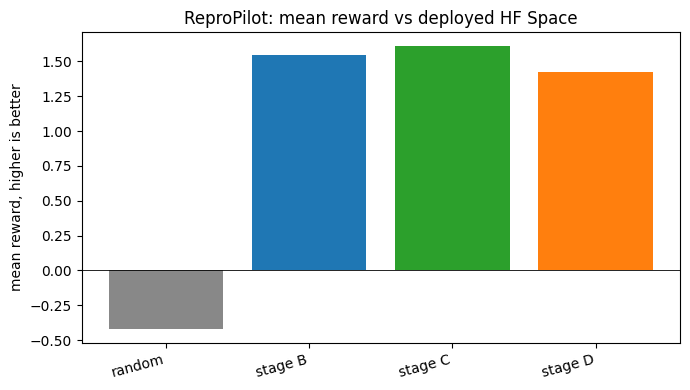

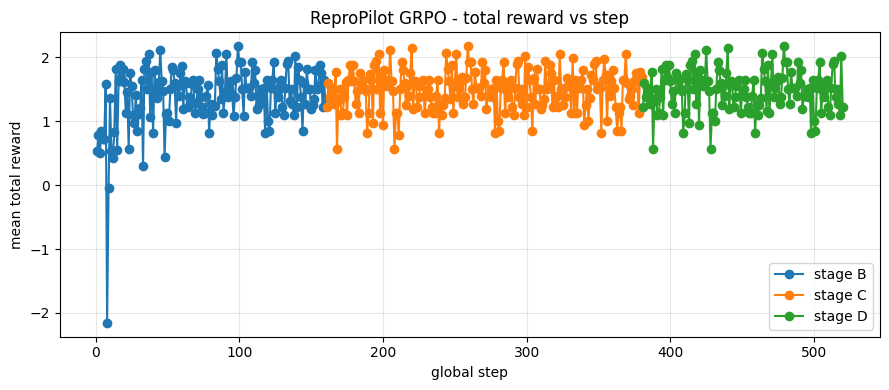

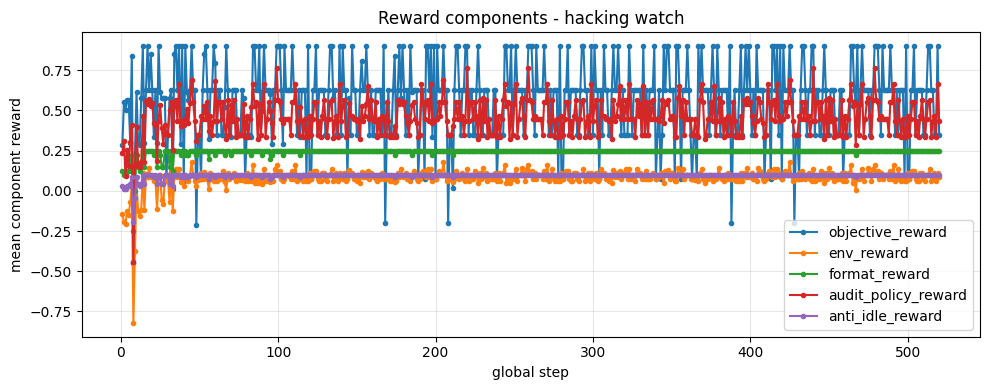

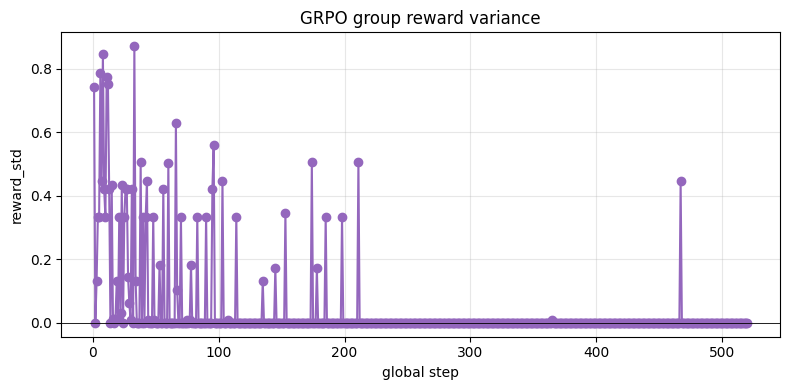

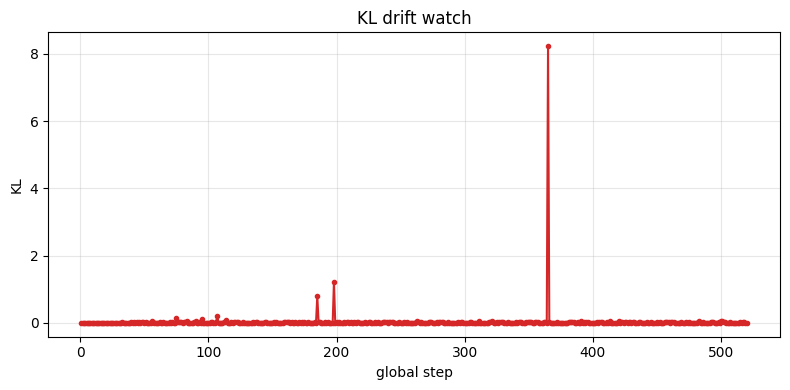

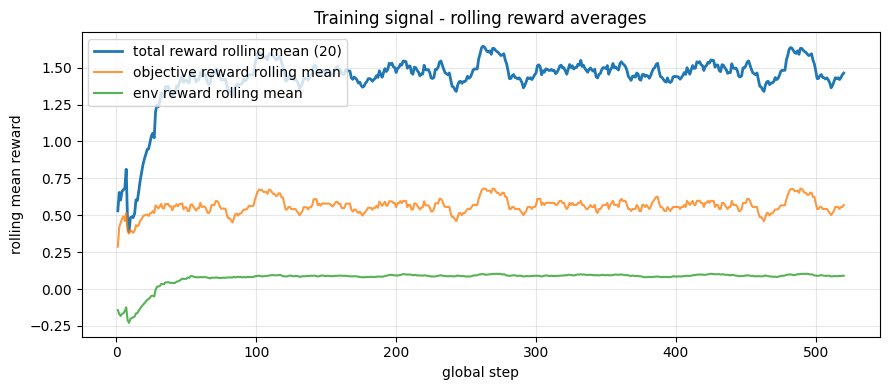

training_health: {
  "window": 20,
  "head_reward_mean": 0.882,
  "tail_reward_mean": 1.4635,
  "reward_delta": 0.5815,
  "tail_objective_mean": 0.57,
  "tail_format_mean": 0.25,
  "tail_env_mean": 0.0898,
  "tail_reward_std_mean": 0.0,
  "bad_tail_steps": 0
}
saved plots/csv to: /content/repropilot_out
space calls: 12617 failures: 5


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


def _log_value(entry: dict, *names: str, default=None):
    for name in names:
        if name in entry:
            return entry[name]
    return default

rows = []
global_step = 0
for stage, log in stage_logs.items():
    for entry in log:
        total = _log_value(entry, 'reward')
        if total is None:
            continue
        global_step += 1
        rows.append({
            'stage': stage,
            'global_step': global_step,
            'reward': total,
            'reward_std': _log_value(entry, 'reward_std', default=0.0),
            'objective': _log_value(entry, 'rewards / objective_reward / mean', 'rewards/objective_reward/mean', default=0.0),
            'env': _log_value(entry, 'rewards / env_reward / mean', 'rewards/env_reward/mean', default=0.0),
            'format': _log_value(entry, 'rewards / format_reward / mean', 'rewards/format_reward/mean', default=0.0),
            'audit_policy': _log_value(entry, 'rewards / audit_policy_reward / mean', 'rewards/audit_policy_reward/mean', default=0.0),
            'anti_idle': _log_value(entry, 'rewards / anti_idle_reward / mean', 'rewards/anti_idle_reward/mean', default=0.0),
            'kl': _log_value(entry, 'kl', default=0.0),
        })

df = pd.DataFrame(rows)
df.to_csv(OUT / 'reward_log.csv', index=False)

summary = {}
if 'random_rewards' in globals() and random_rewards:
    summary['random'] = sum(random_rewards) / len(random_rewards)
if not df.empty:
    for stage, sub in df.groupby('stage'):
        tail = sub.tail(min(5, len(sub)))
        summary[f'stage {stage}'] = float(tail['reward'].mean())

if summary:
    plt.figure(figsize=(7, 4))
    colors = ['#888888', '#1f77b4', '#2ca02c', '#ff7f0e'][:len(summary)]
    plt.bar(list(summary.keys()), list(summary.values()), color=colors)
    plt.title('ReproPilot: mean reward vs deployed HF Space')
    plt.ylabel('mean reward, higher is better')
    plt.axhline(0.0, color='black', linewidth=0.6)
    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    plt.savefig(OUT / 'before_after.png', dpi=150)
    plt.show()
else:
    print('No summary rewards available yet.')

if not df.empty:
    plt.figure(figsize=(9, 4))
    for stage, sub in df.groupby('stage'):
        plt.plot(sub['global_step'], sub['reward'], marker='o', label=f'stage {stage}')
    plt.xlabel('global step')
    plt.ylabel('mean total reward')
    plt.title('ReproPilot GRPO - total reward vs step')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUT / 'reward_curve.png', dpi=150)
    plt.show()

    plt.figure(figsize=(10, 4))
    for col, label in [
        ('objective', 'objective_reward'),
        ('env', 'env_reward'),
        ('format', 'format_reward'),
        ('audit_policy', 'audit_policy_reward'),
        ('anti_idle', 'anti_idle_reward'),
    ]:
        plt.plot(df['global_step'], df[col], marker='.', label=label)
    plt.xlabel('global step')
    plt.ylabel('mean component reward')
    plt.title('Reward components - hacking watch')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUT / 'components.png', dpi=150)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(df['global_step'], df['reward_std'], marker='o', color='#9467bd')
    plt.xlabel('global step')
    plt.ylabel('reward_std')
    plt.title('GRPO group reward variance')
    plt.axhline(0.0, color='black', linewidth=0.6)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUT / 'reward_std.png', dpi=150)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(df['global_step'], df['kl'], marker='.', color='#d62728')
    plt.xlabel('global step')
    plt.ylabel('KL')
    plt.title('KL drift watch')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUT / 'kl_curve.png', dpi=150)
    plt.show()
else:
    print('No numeric reward log found - skipping curve plots.')

if not df.empty:
    window = min(20, max(3, len(df) // 5))
    df['rolling_reward'] = df['reward'].rolling(window=window, min_periods=1).mean()
    df['rolling_objective'] = df['objective'].rolling(window=window, min_periods=1).mean()
    df['rolling_env'] = df['env'].rolling(window=window, min_periods=1).mean()
    df.to_csv(OUT / 'reward_log.csv', index=False)

    plt.figure(figsize=(9, 4))
    plt.plot(df['global_step'], df['rolling_reward'], label=f'total reward rolling mean ({window})', linewidth=2)
    plt.plot(df['global_step'], df['rolling_objective'], label='objective reward rolling mean', alpha=0.8)
    plt.plot(df['global_step'], df['rolling_env'], label='env reward rolling mean', alpha=0.8)
    plt.xlabel('global step')
    plt.ylabel('rolling mean reward')
    plt.title('Training signal - rolling reward averages')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUT / 'rolling_reward.png', dpi=150)
    plt.show()

    head = df.head(window)
    tail = df.tail(window)
    training_health = {
        'window': int(window),
        'head_reward_mean': round(float(head['reward'].mean()), 4),
        'tail_reward_mean': round(float(tail['reward'].mean()), 4),
        'reward_delta': round(float(tail['reward'].mean() - head['reward'].mean()), 4),
        'tail_objective_mean': round(float(tail['objective'].mean()), 4),
        'tail_format_mean': round(float(tail['format'].mean()), 4),
        'tail_env_mean': round(float(tail['env'].mean()), 4),
        'tail_reward_std_mean': round(float(tail['reward_std'].mean()), 4),
        'bad_tail_steps': int((tail['reward'] < 0).sum()),
    }
    print('training_health:', json.dumps(training_health, indent=2))
    if training_health['tail_objective_mean'] < 0.45:
        print('warning: objective routing is still weak; run more SFT or lower GRPO temperature.')
    if training_health['tail_format_mean'] < 0.20:
        print('warning: JSON format is weak; inspect samples before continuing.')
    if training_health['reward_delta'] <= 0 and training_health['bad_tail_steps'] > len(tail) // 3:
        print('warning: tail reward is not improving cleanly; reduce LR or add more SFT examples.')

print('saved plots/csv to:', OUT)
print('space calls:', len(env.latency_ms), 'failures:', len(env.failures))


## Phase 9 - Save And Push

This saves the LoRA adapter locally. Set `PUSH_TO_HUB=1` before the notebook run, or run the login cell here and push manually.


In [ ]:
ADAPTER_DIR = OUT / 'final_adapter'
policy.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
print('saved adapter:', ADAPTER_DIR)

if PUSH_TO_HUB:
    from huggingface_hub import login, notebook_login
    token = os.environ.get('HF_TOKEN')
    if token:
        login(token=token)
    else:
        notebook_login()
    policy.push_to_hub(HUB_REPO_ID, commit_message=f'ReproPilot GRPO adapter ({RUN_NAME})')
    tokenizer.push_to_hub(HUB_REPO_ID)
    print('pushed:', HUB_REPO_ID)
else:
    print('push disabled; set PUSH_TO_HUB=1 and HF_MODEL_REPO_ID to upload')


Unsloth: Restored added_tokens_decoder metadata in /content/repropilot_out/final_adapter/tokenizer_config.json.


saved adapter: /content/repropilot_out/final_adapter
push disabled; set PUSH_TO_HUB=1 and HF_MODEL_REPO_ID to upload


## Phase 10 - Run Manifest


In [ ]:
manifest = {
    'run_name': RUN_NAME,
    'env_url': REPROPILOT_ENV_URL,
    'model_id': MODEL_ID,
    'hub_repo_id': HUB_REPO_ID if PUSH_TO_HUB else None,
    'n_space_calls': len(env.latency_ms),
    'mean_space_latency_ms': round(sum(env.latency_ms) / max(len(env.latency_ms), 1), 1),
    'space_failures_tail': env.failures[-10:],
    'out': str(OUT),
}
(OUT / 'manifest.json').write_text(json.dumps(manifest, indent=2), encoding='utf-8')
print(json.dumps(manifest, indent=2))


{
  "run_name": "repropilot-unsloth-grpo-live-api",
  "env_url": "https://riwaj43adz-repro.hf.space",
  "model_id": "unsloth/Qwen2.5-3B-Instruct",
  "hub_repo_id": null,
  "n_space_calls": 12617,
  "mean_space_latency_ms": 180.4,
  "space_failures_tail": [
    "422 https://riwaj43adz-repro.hf.space/step: {\"detail\":[{\"type\":\"enum\",\"loc\":[\"failure_type\"],\"msg\":\"Input should be 'none', 'metric_mismatch', 'split_mismatch', 'data_leakage', 'cherry_picked_seed', 'paper_code_mismatch', 'invalid_ablation', 'result_mismatch', 'missing_artifact', 'dataset_provenance_issue', 'hyperparameter_search_bias', 'baseline_unfairness', 'statistical_underpower', 'incomplete_implementation', 'ambiguous_method', 'unsupported_claim' or 'unknown'\",\"input\":\"\",\"ctx\":{\"expected\":\"'none', 'metric_mismatch', 'split_mismatch', 'data_leakage', 'cherry_picked_seed', 'paper_code_mismatch', 'invalid_ablation', 'result_mismatch', 'missing_artifact', 'dataset_provenance_issue', 'hyperparameter_searc

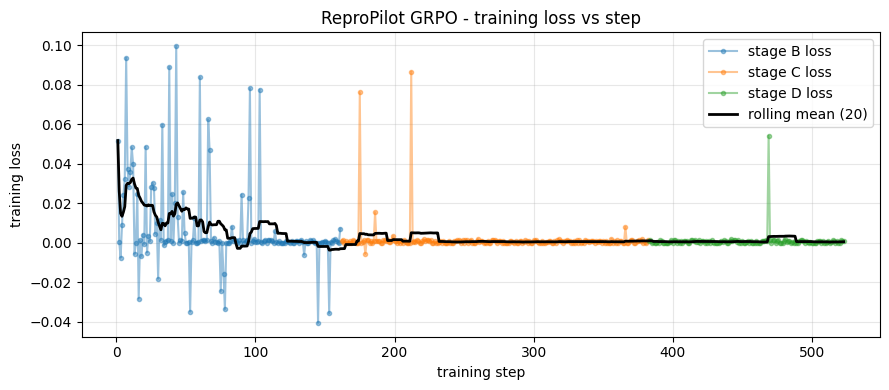

saved loss plot: /content/repropilot_out/loss_curve.png


In [22]:
import pandas as pd
import matplotlib.pyplot as plt

loss_rows = []
global_loss_step = 0
for stage, log in stage_logs.items():
    for entry in log:
        loss = entry.get('loss')
        if loss is None:
            loss = entry.get('train_loss')
        if loss is None:
            loss = entry.get('training_loss')
        if loss is None:
            continue
        global_loss_step += 1
        loss_rows.append({
            'stage': stage,
            'global_step': global_loss_step,
            'loss': float(loss),
        })

loss_df = pd.DataFrame(loss_rows)
loss_df.to_csv(OUT / 'loss_log.csv', index=False)

if not loss_df.empty:
    window = min(20, max(3, len(loss_df) // 5))
    loss_df['rolling_loss'] = loss_df['loss'].rolling(window=window, min_periods=1).mean()
    loss_df.to_csv(OUT / 'loss_log.csv', index=False)

    plt.figure(figsize=(9, 4))
    for stage, sub in loss_df.groupby('stage'):
        plt.plot(sub['global_step'], sub['loss'], marker='.', alpha=0.45, label=f'stage {stage} loss')
    plt.plot(loss_df['global_step'], loss_df['rolling_loss'], color='black', linewidth=2, label=f'rolling mean ({window})')
    plt.xlabel('training step')
    plt.ylabel('training loss')
    plt.title('ReproPilot GRPO - training loss vs step')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUT / 'loss_curve.png', dpi=150)
    plt.show()
    print('saved loss plot:', OUT / 'loss_curve.png')
else:
    print('No loss entries found in stage_logs. Check trainer.state.log_history keys:')
    if stage_logs:
        first_stage = next(iter(stage_logs))
        first_log = stage_logs[first_stage][:3]
        print(first_log)

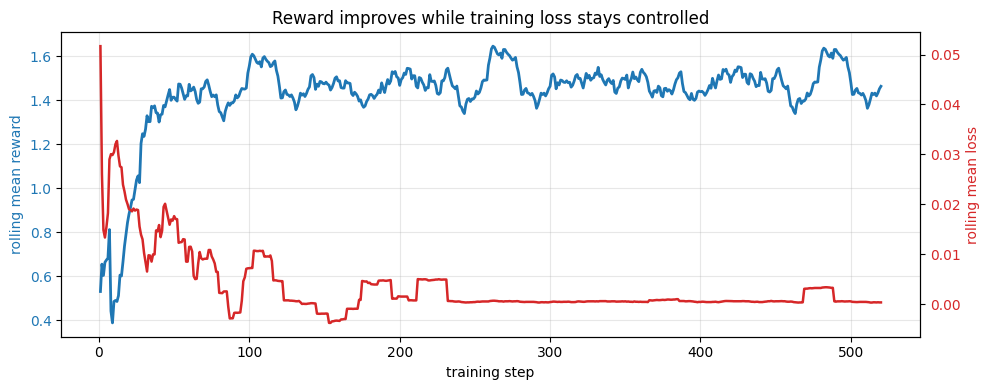

/tmp/ipykernel_1979/533000111.py:57: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[f'stage {s}' for s in stages], showmeans=True)


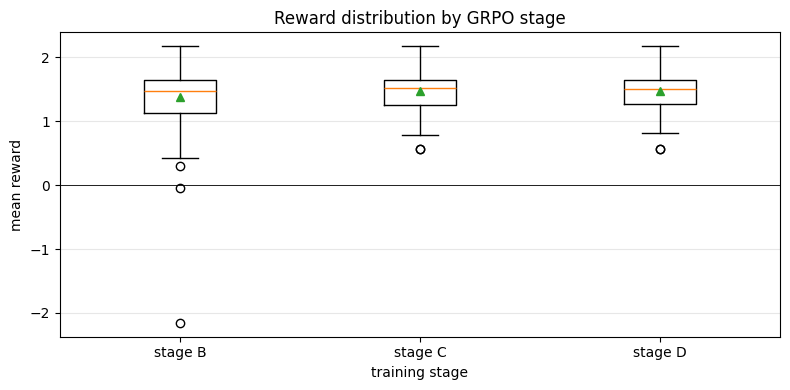

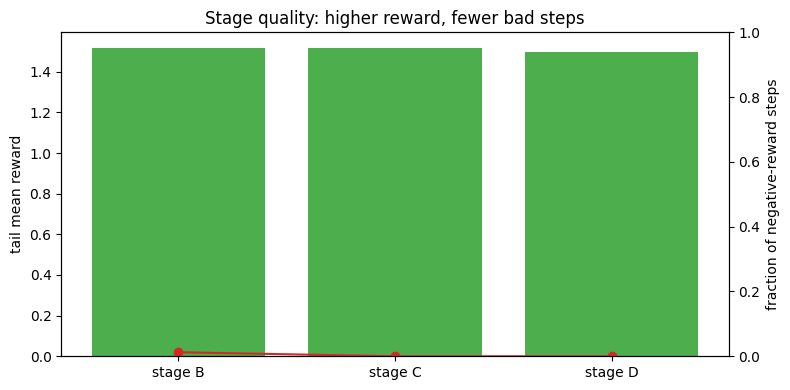

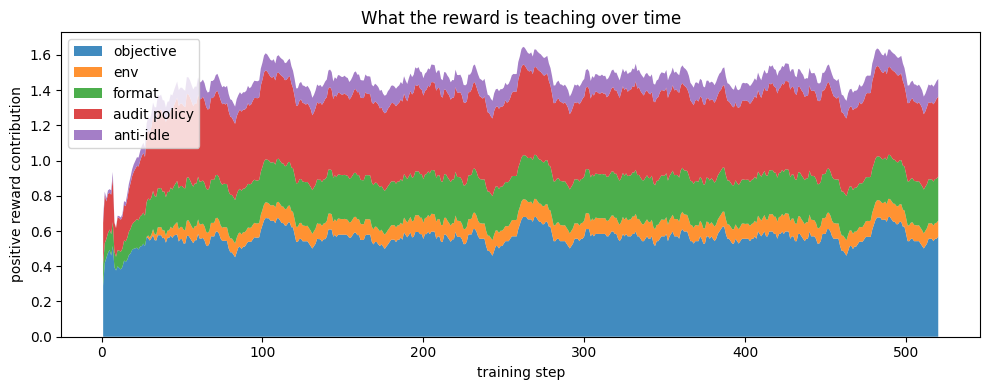

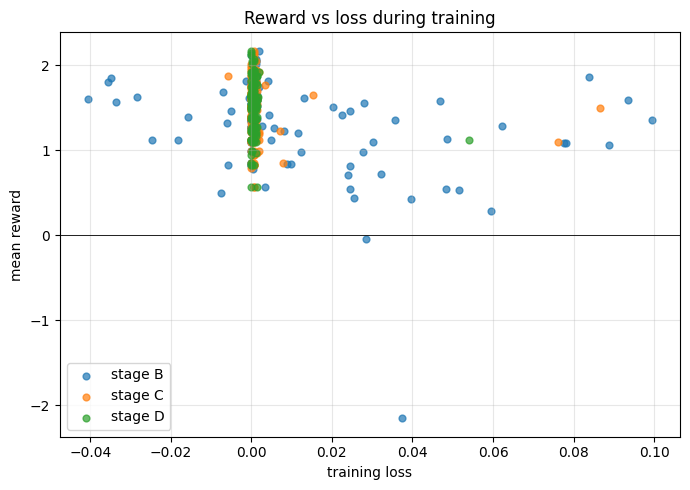

extra analytics saved to: /content/repropilot_out
  stage  mean_reward  tail_reward  reward_gain_vs_head  mean_env_reward  \
0     B     1.371626     1.518178             1.033758         0.057277   
1     C     1.479257     1.514785             0.159919         0.090962   
2     D     1.478206     1.495015             0.140148         0.091510   

   mean_objective_reward  bad_step_rate  
0               0.556901         0.0125  
1               0.570398         0.0000  
2               0.569583         0.0000  


In [23]:
import pandas as pd
import matplotlib.pyplot as plt

if 'df' not in globals() or df.empty:
    print('Run Phase 8 first so reward dataframe df exists.')
else:
    plot_df = df.copy()
    if 'loss_df' in globals() and not loss_df.empty:
        merged = pd.merge_asof(
            plot_df.sort_values('global_step'),
            loss_df[['global_step', 'loss']].sort_values('global_step'),
            on='global_step',
            direction='nearest',
        )
    else:
        merged = plot_df.copy()
        merged['loss'] = None

    stage_summary = []
    for stage, sub in plot_df.groupby('stage'):
        first = sub.head(min(10, len(sub)))
        tail = sub.tail(min(10, len(sub)))
        stage_summary.append({
            'stage': stage,
            'mean_reward': float(sub['reward'].mean()),
            'tail_reward': float(tail['reward'].mean()),
            'reward_gain_vs_head': float(tail['reward'].mean() - first['reward'].mean()),
            'mean_env_reward': float(sub['env'].mean()),
            'mean_objective_reward': float(sub['objective'].mean()),
            'bad_step_rate': float((sub['reward'] < 0).mean()),
        })
    stage_summary_df = pd.DataFrame(stage_summary)
    stage_summary_df.to_csv(OUT / 'stage_summary.csv', index=False)

    # 1. Reward and loss on shared training timeline.
    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax1.plot(plot_df['global_step'], plot_df['rolling_reward'], color='#1f77b4', linewidth=2, label='rolling reward')
    ax1.set_xlabel('training step')
    ax1.set_ylabel('rolling mean reward', color='#1f77b4')
    ax1.tick_params(axis='y', labelcolor='#1f77b4')
    ax1.grid(True, alpha=0.3)
    if 'loss' in merged and merged['loss'].notna().any():
        ax2 = ax1.twinx()
        loss_series = merged['loss'].rolling(window=min(20, max(3, len(merged) // 5)), min_periods=1).mean()
        ax2.plot(merged['global_step'], loss_series, color='#d62728', linewidth=1.8, label='rolling loss')
        ax2.set_ylabel('rolling mean loss', color='#d62728')
        ax2.tick_params(axis='y', labelcolor='#d62728')
    plt.title('Reward improves while training loss stays controlled')
    fig.tight_layout()
    plt.savefig(OUT / 'reward_loss_dual_axis.png', dpi=150)
    plt.show()

    # 2. Per-stage reward distribution.
    plt.figure(figsize=(8, 4))
    stages = list(plot_df['stage'].drop_duplicates())
    data = [plot_df.loc[plot_df['stage'] == stage, 'reward'] for stage in stages]
    plt.boxplot(data, labels=[f'stage {s}' for s in stages], showmeans=True)
    plt.axhline(0.0, color='black', linewidth=0.6)
    plt.xlabel('training stage')
    plt.ylabel('mean reward')
    plt.title('Reward distribution by GRPO stage')
    plt.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUT / 'reward_distribution_by_stage.png', dpi=150)
    plt.show()

    # 3. Stage summary bars: tail reward and bad-step rate.
    if not stage_summary_df.empty:
        x = range(len(stage_summary_df))
        fig, ax1 = plt.subplots(figsize=(8, 4))
        ax1.bar(x, stage_summary_df['tail_reward'], color='#2ca02c', alpha=0.85, label='tail reward')
        ax1.set_ylabel('tail mean reward')
        ax1.set_xticks(list(x))
        ax1.set_xticklabels([f'stage {s}' for s in stage_summary_df['stage']])
        ax1.axhline(0.0, color='black', linewidth=0.6)
        ax2 = ax1.twinx()
        ax2.plot(x, stage_summary_df['bad_step_rate'], color='#d62728', marker='o', label='bad-step rate')
        ax2.set_ylabel('fraction of negative-reward steps')
        ax2.set_ylim(0, max(1.0, float(stage_summary_df['bad_step_rate'].max()) * 1.2))
        plt.title('Stage quality: higher reward, fewer bad steps')
        fig.tight_layout()
        plt.savefig(OUT / 'stage_quality_summary.png', dpi=150)
        plt.show()

    # 4. Reward component stacked area.
    component_cols = ['objective', 'env', 'format', 'audit_policy', 'anti_idle']
    component_smooth = plot_df[component_cols].rolling(window=min(20, max(3, len(plot_df) // 5)), min_periods=1).mean()
    positive_components = component_smooth.clip(lower=0)
    plt.figure(figsize=(10, 4))
    plt.stackplot(
        plot_df['global_step'],
        [positive_components[col] for col in component_cols],
        labels=['objective', 'env', 'format', 'audit policy', 'anti-idle'],
        alpha=0.85,
    )
    plt.xlabel('training step')
    plt.ylabel('positive reward contribution')
    plt.title('What the reward is teaching over time')
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.savefig(OUT / 'reward_component_stack.png', dpi=150)
    plt.show()

    # 5. Reward vs loss scatter, useful for showing stable optimization.
    if 'loss' in merged and merged['loss'].notna().any():
        plt.figure(figsize=(7, 5))
        for stage, sub in merged.groupby('stage'):
            good = sub.dropna(subset=['loss'])
            if not good.empty:
                plt.scatter(good['loss'], good['reward'], s=24, alpha=0.7, label=f'stage {stage}')
        plt.xlabel('training loss')
        plt.ylabel('mean reward')
        plt.title('Reward vs loss during training')
        plt.axhline(0.0, color='black', linewidth=0.6)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.savefig(OUT / 'reward_vs_loss_scatter.png', dpi=150)
        plt.show()

    print('extra analytics saved to:', OUT)
    print(stage_summary_df)
